# NeuralRetail Intelligence Platform

An end-to-end retail analytics and machine learning pipeline built on the **Online Retail II** transactional dataset (UCI Machine Learning Repository; 1,067,371 raw records). The project covers customer segmentation, demand forecasting, churn prediction, inventory optimization, cohort retention, market basket analysis and customer lifetime value estimation.

**Libraries:** pandas, NumPy, scikit-learn, XGBoost, Prophet, mlxtend, matplotlib, seaborn.

## Modules

1. Data cleaning and missing-value bias assessment
2. Exploratory data analysis (core KPIs)
3. RFM analysis and rule-based customer segmentation
4. KMeans clustering (Elbow method with Silhouette validation)
5. Demand forecasting with Prophet (holdout validation)
6. Churn prediction (feature engineering, cross-validation, hyperparameter tuning)
7. Inventory optimization (reorder point with safety stock)
8. Cohort retention analysis
9. Market basket analysis (Apriori)
10. Customer lifetime value (CLV) with sanity checks

## Methodological Highlights

- **Bias assessment:** quantifies whether the ~23% of rows dropped for a missing Customer ID differ systematically from the rows that are kept.
- **Leakage-free churn modelling:** Recency is excluded from the features because it defines the churn label; three additional behavioural features (Product_Diversity, Avg_Days_Between_Orders, Return_Rate) are engineered.
- **Model validation:** stratified 5-fold cross-validation and GridSearchCV hyperparameter tuning for the churn model.
- **Cluster validation:** the Elbow method is cross-checked with the Silhouette Score, and cluster labels are assigned dynamically and verified with assertions.
- **Forecast validation:** a six-month holdout test reports MAPE instead of relying on the forecast plot alone.
- **Inventory:** the reorder point includes a safety-stock buffer based on demand variability.
- **Interpretability:** churn feature importance identifies which customer behaviours to monitor.
- **CLV sanity check:** the projected CLV values are checked for negative values and edge-case distortion.

## Business Assumptions

- A customer is considered churned if there has been no purchase in the last 90 days (Recency > 90).
- Supplier lead time is 7 days, and average daily demand is computed as total quantity sold divided by 30.
- The safety-stock service level is approximately 95% (Z = 1.65).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


## 1. Load Data

In [2]:
df = pd.read_csv('online_retail_II.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.shape

(1067371, 8)

In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(34335)

## 2. Data Cleaning

Duplicate rows are removed. Rows without a Customer ID, rows with non-positive quantity or price, and cancelled invoices (prefixed with "C") are excluded. A `TotalPrice` field is derived as Quantity × Price.

In [6]:
retail = df.copy()

returns_df = retail[
    (retail['Quantity'] < 0) |
    (retail['Invoice'].astype(str).str.startswith('C'))
]

retail.drop_duplicates(inplace=True)

# keep a snapshot BEFORE the Customer-ID drop, needed for the bias check below
retail_before_id_drop = retail.copy()

retail = retail.dropna(subset=['Customer ID'])
retail['Description'] = retail['Description'].fillna('Unknown')
retail = retail[retail['Quantity'] > 0]
retail = retail[retail['Price'] > 0]
retail = retail[~retail['Invoice'].astype(str).str.startswith('C')]
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])
retail['TotalPrice'] = retail['Quantity'] * retail['Price']

retail.shape

(779425, 9)

### 2.1 Bias Assessment: Rows with Missing Customer ID

Rows without a Customer ID (approximately 23% of the de-duplicated data) are excluded from the customer-level analysis. To assess whether this exclusion introduces bias, the average Quantity, Price and TotalPrice of the excluded rows are compared with those of the retained rows, using a snapshot taken immediately before the drop (after de-duplication).

In [7]:
missing_id = retail_before_id_drop[retail_before_id_drop['Customer ID'].isna()]
has_id = retail_before_id_drop[retail_before_id_drop['Customer ID'].notna()]

bias_check = pd.DataFrame({
    'Missing_CustomerID': [
        len(missing_id),
        missing_id['Quantity'].mean(),
        missing_id['Price'].mean(),
        (missing_id['Quantity'] * missing_id['Price']).mean(),
    ],
    'Has_CustomerID': [
        len(has_id),
        has_id['Quantity'].mean(),
        has_id['Price'].mean(),
        (has_id['Quantity'] * has_id['Price']).mean(),
    ],
}, index=['Row_Count', 'Avg_Quantity', 'Avg_Price', 'Avg_TotalPrice'])

bias_check

,Missing_CustomerID,Has_CustomerID
Row_Count,235151.000000,797885.000000
Avg_Quantity,1.505628,12.602980
Avg_Price,7.705913,3.702732
Avg_TotalPrice,10.910191,20.416465


**Finding:** Rows with a missing Customer ID have a much lower average Quantity (~1.5 vs ~12.6 units) and a lower average transaction value (~£10.9 vs ~£20.4), but a higher average unit Price (~£7.7 vs ~£3.7). The exclusion is therefore not neutral: it disproportionately removes small, low-quantity, higher-unit-price transactions that resemble guest checkouts or manual/adjustment entries. Consequently, the customer-level analyses (RFM, churn and CLV) represent **identified, repeat-shopping customers** rather than every transaction in the store.

## 3. Outlier Analysis

Outliers in Quantity are flagged using the interquartile range (IQR) rule and are retained for the downstream analysis.

In [8]:
Q1 = retail['Quantity'].quantile(0.25)
Q3 = retail['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = retail[(retail['Quantity'] < lower_bound) | (retail['Quantity'] > upper_bound)]
print("Lower Bound:", lower_bound, "| Upper Bound:", upper_bound)
print("Outlier rows:", outliers.shape[0])

Lower Bound: -13.0 | Upper Bound: 27.0
Outlier rows: 51119


## 4. Exploratory Data Analysis: Core KPIs

In [9]:
total_revenue = retail['TotalPrice'].sum()
total_orders = retail['Invoice'].nunique()
total_customers = retail['Customer ID'].nunique()
total_products = retail['StockCode'].nunique()

summary = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Orders', 'Total Customers', 'Total Products'],
    'Value': [total_revenue, total_orders, total_customers, total_products]
})
summary

,Metric,Value
0,Total Revenue,1.737480e+07
1,Total Orders,3.696900e+04
2,Total Customers,5.878000e+03
3,Total Products,4.631000e+03


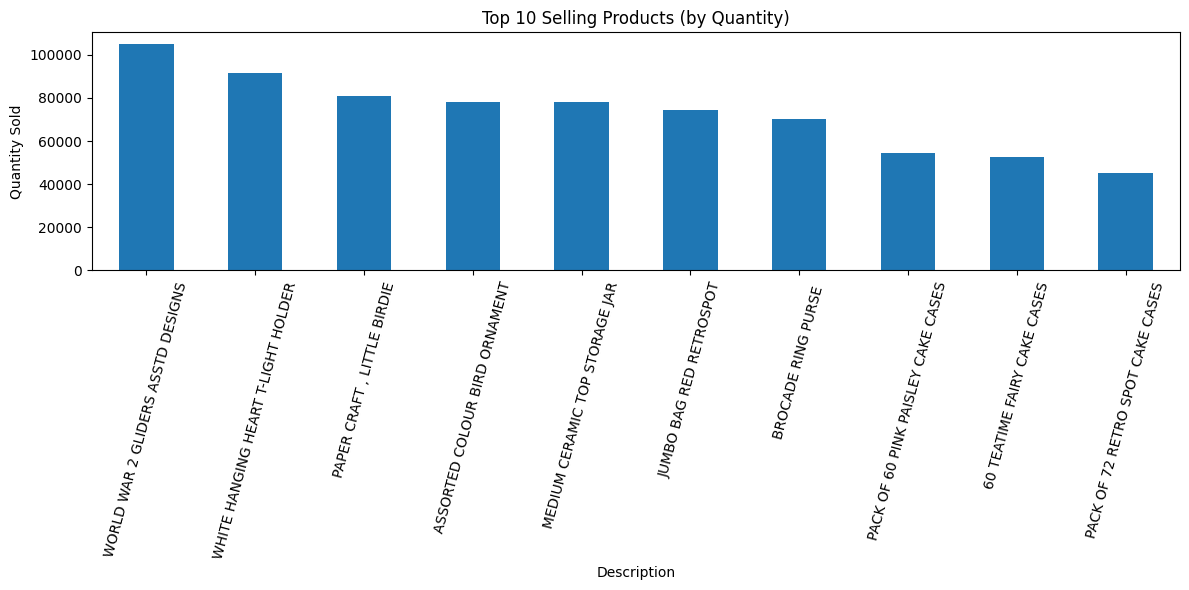

In [10]:
top_products = retail.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products (by Quantity)")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

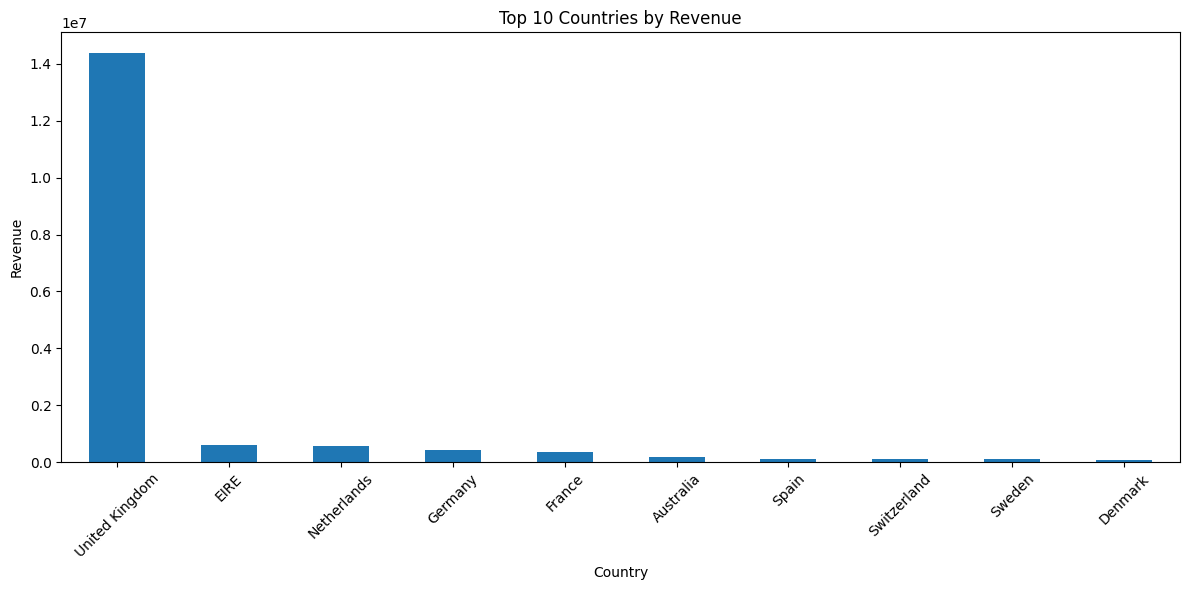

In [11]:
top_countries = retail.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

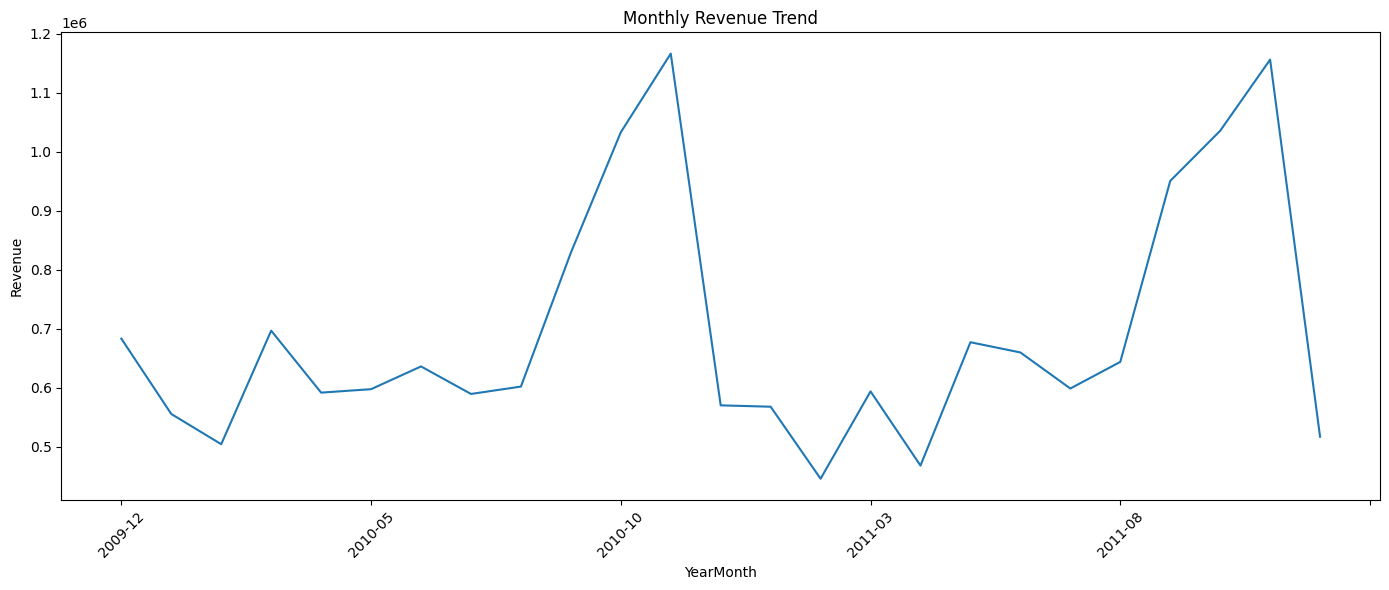

In [12]:
retail['YearMonth'] = retail['InvoiceDate'].dt.to_period('M')
monthly_sales = retail.groupby('YearMonth')['TotalPrice'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. RFM Analysis and Rule-Based Segmentation

Recency, Frequency and Monetary values are computed for each customer, scored in quartiles, and used to assign customers to rule-based segments.

In [13]:
snapshot_date = retail['InvoiceDate'].max()
rfm = retail.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,342.280000
50%,95.000000,3.000000,867.740000
75%,379.000000,7.000000,2248.305000
max,738.000000,398.000000,580987.040000


In [14]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

def customer_segment(row):
    if row['RFM_Score'] == '444':
        return 'VIP Customer'
    elif row['R_Score'] == 4 and row['F_Score'] >= 3:
        return 'Loyal Customer'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'Potential Customer'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk Customer'
    else:
        return 'Regular Customer'

rfm['Segment'] = rfm.apply(customer_segment, axis=1)
rfm['Segment'].value_counts()

Segment
Regular Customer      2930
Potential Customer     894
At Risk Customer       880
VIP Customer           659
Loyal Customer         515
Name: count, dtype: int64

## 6. KMeans Clustering

Recency, Frequency and Monetary features are standardised before clustering. The Elbow method is used to explore candidate values of k.

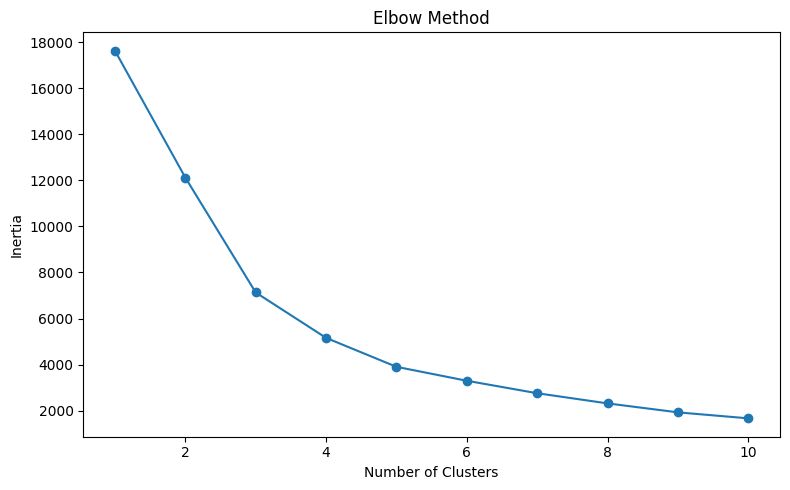

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

inertia = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

### 6.1 Cluster Count Validation: Silhouette Score

The Silhouette Score provides a quantitative check on the choice of k suggested by the Elbow plot. Values closer to 1 indicate better-separated, more cohesive clusters.

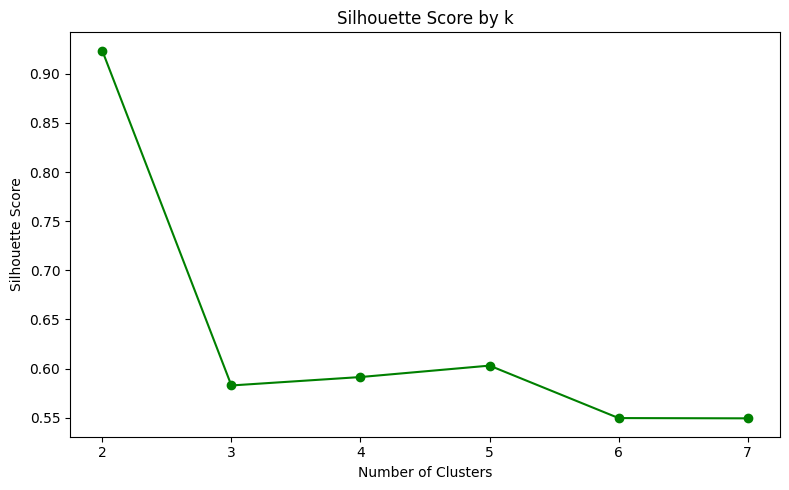

,k,silhouette_score
0,2,0.923555
1,3,0.582746
2,4,0.591319
3,5,0.602951
4,6,0.549545
5,7,0.549273


In [16]:
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    sil_scores[k] = silhouette_score(rfm_scaled, labels)

sil_df = pd.DataFrame({'k': list(sil_scores.keys()), 'silhouette_score': list(sil_scores.values())})
plt.figure(figsize=(8,5))
plt.plot(sil_df['k'], sil_df['silhouette_score'], marker='o', color='green')
plt.title("Silhouette Score by k")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()
sil_df

**Finding:** The Silhouette Score is highest at k = 2 (≈ 0.92), while k = 3 scores ≈ 0.58 and k = 4–5 score comparably (≈ 0.59–0.60). k = 3 was selected because it yields three business-interpretable segments (At Risk, Loyal, VIP), including a very small high-value group, which is more actionable than the statistically cleaner two-cluster solution. This is a deliberate trade-off of business usefulness over the maximum Silhouette Score.

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,65.296335,7.640239,3136.130157
1,460.861125,2.205077,747.333351
2,22.090909,143.045455,173123.584091


In [18]:
cluster_names = {
    cluster_summary['Monetary'].idxmin(): 'At Risk Customers',
}
remaining = [c for c in cluster_summary.index if c not in cluster_names]
sorted_remaining = cluster_summary.loc[remaining].sort_values('Monetary')
cluster_names[sorted_remaining.index[0]] = 'Loyal Customers'
cluster_names[sorted_remaining.index[1]] = 'VIP Customers'

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_names)
rfm['Cluster_Label'].value_counts()

Cluster_Label
Loyal Customers      3847
At Risk Customers    2009
VIP Customers          22
Name: count, dtype: int64

### 6.2 Cluster Label Assignment and Verification

Cluster names are assigned dynamically from each cluster's mean Monetary value (lowest: At Risk, middle: Loyal, highest: VIP) rather than from hardcoded cluster IDs, because KMeans cluster numbers are arbitrary and can change between runs. The check below confirms that the assigned labels are consistent with the observed Recency, Frequency and Monetary profile of each cluster.

In [19]:
verify = cluster_summary.copy()
verify['Assigned_Label'] = verify.index.map(cluster_names)
verify['Customer_Count'] = rfm['Cluster'].value_counts()
print(verify.sort_values('Monetary'))

assert verify.loc[verify['Monetary'].idxmin(), 'Assigned_Label'] == 'At Risk Customers'
assert verify.loc[verify['Monetary'].idxmax(), 'Assigned_Label'] == 'VIP Customers'
print("\nCluster label mapping verified correct: lowest-Monetary cluster = At Risk, "
      "highest-Monetary cluster = VIP, middle = Loyal.")

            Recency   Frequency       Monetary     Assigned_Label  \
Cluster                                                             
1        460.861125    2.205077     747.333351  At Risk Customers   
0         65.296335    7.640239    3136.130157    Loyal Customers   
2         22.090909  143.045455  173123.584091      VIP Customers   

         Customer_Count  
Cluster                  
1                  2009  
0                  3847  
2                    22  

Cluster label mapping verified correct: lowest-Monetary cluster = At Risk, highest-Monetary cluster = VIP, middle = Loyal.


## 7. Demand Forecasting with Prophet

Monthly revenue is forecast six months ahead using Prophet.

In [20]:
from prophet import Prophet

forecast_data = retail.groupby('YearMonth')['TotalPrice'].sum().reset_index()
forecast_data['YearMonth'] = forecast_data['YearMonth'].astype(str)
forecast_data.columns = ['ds', 'y']
forecast_data['ds'] = pd.to_datetime(forecast_data['ds'])

model = Prophet()
model.fit(forecast_data)

future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6)

Importing plotly failed. Interactive plots will not work.


20:37:33 - cmdstanpy - INFO - Chain [1] start processing


20:37:34 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
25,2012-01-01,689971.649364,681136.732129,698397.990609
26,2012-02-01,475724.918502,466625.277338,485676.895371
27,2012-03-01,718080.584923,706839.106697,729501.711530
28,2012-04-01,728823.641918,714247.646805,743131.599274
29,2012-05-01,394522.615116,377489.609956,410139.824711
30,2012-06-01,607318.932096,585676.961289,625729.195269


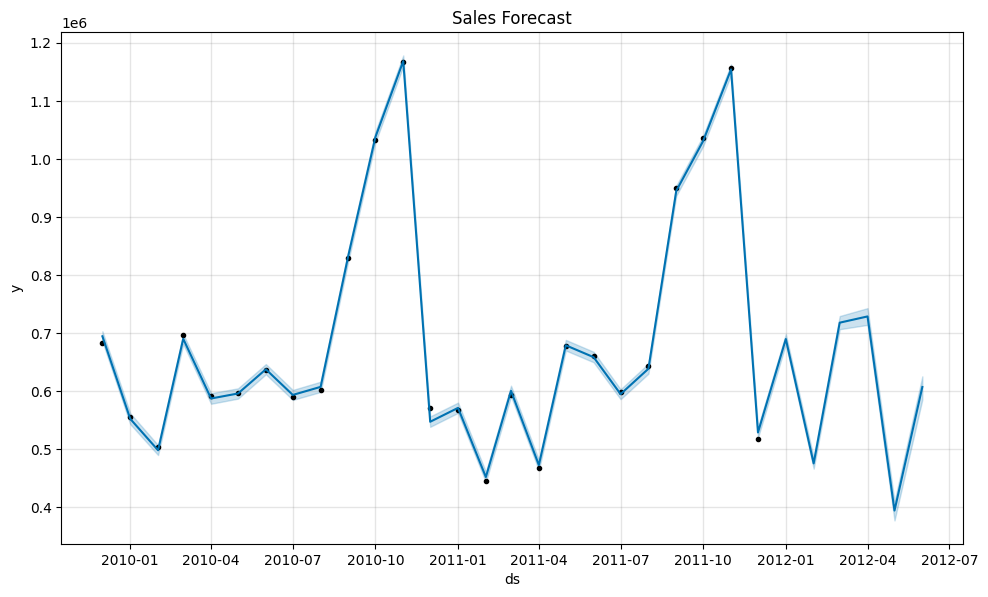

In [21]:
fig1 = model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

### 7.1 Forecast Validation: Holdout Test

Forecast accuracy is evaluated with a holdout test. Prophet is trained on all months except the last six, predicts those six months, and the predictions are compared with actual revenue using Mean Absolute Percentage Error (MAPE).

In [22]:
train_data = forecast_data.iloc[:-6]
test_data = forecast_data.iloc[-6:]
print("Training months:", len(train_data), "| Holdout months:", len(test_data))

holdout_model = Prophet()
holdout_model.fit(train_data)

holdout_future = holdout_model.make_future_dataframe(periods=6, freq='MS')
holdout_forecast = holdout_model.predict(holdout_future)

pred_indexed = holdout_forecast.set_index('ds')
pred_indexed.index = pred_indexed.index.to_period('M')
test_indexed = test_data.set_index('ds')
test_indexed.index = test_indexed.index.to_period('M')

predicted = pred_indexed.loc[test_indexed.index]['yhat']
actual = test_indexed['y']

mape = (np.abs((actual.values - predicted.values) / actual.values)).mean() * 100

holdout_comparison = pd.DataFrame({'Actual_Revenue': actual.values, 'Predicted_Revenue': predicted.values}, index=test_indexed.index)
holdout_comparison['Error_%'] = (np.abs(holdout_comparison['Actual_Revenue'] - holdout_comparison['Predicted_Revenue']) / holdout_comparison['Actual_Revenue'] * 100).round(1)
print(holdout_comparison)
print(f"\nMAPE on last 6 months (held out): {mape:.1f}%")

20:37:34 - cmdstanpy - INFO - Chain [1] start processing


20:37:34 - cmdstanpy - INFO - Chain [1] done processing


Training months: 19 | Holdout months: 6
         Actual_Revenue  Predicted_Revenue  Error_%
ds                                                 
2011-07      598962.901      663873.757637     10.8
2011-08      644051.040      664644.519097      3.2
2011-09      950690.202      665415.280557     30.0
2011-10     1035642.450      666161.178745     35.7
2011-11     1156205.610      666931.940205     42.3
2011-12      517208.440      667677.838393     29.1

MAPE on last 6 months (held out): 25.2%


**Finding:** MAPE on the six held-out months is approximately **25%**, meaning the forecast deviates from actual revenue by about a quarter on average. The month-by-month comparison shows that the model **underpredicts the September–November peak** (errors of 30–42%). The pre-holiday surge recurs every year, but with only ~19 months of training history Prophet has not observed enough yearly cycles to learn this seasonality reliably. The forecast is therefore a reasonable trend-level estimate, but it is not suitable for tight inventory or cash-flow commitments. At least two full years of history would allow the yearly seasonality component to capture the holiday peak.

## 8. Churn Prediction

A customer is labelled as churned if there has been no purchase in the last 90 days (Recency > 90). Models are trained on behavioural features that do not include Recency.

In [23]:
rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)
rfm['Churn'].value_counts()

Churn
1    2985
0    2893
Name: count, dtype: int64

### 8.1 Leakage-Free Feature Engineering

Because the churn label is derived from Recency, Recency is excluded from the feature set to prevent target leakage. The models use Frequency and Monetary together with three engineered behavioural features that do not depend on Recency:

- **Product_Diversity:** number of unique products a customer has purchased (unique StockCodes).
- **Avg_Days_Between_Orders:** average gap between a customer's orders (repeat-buying rhythm).
- **Return_Rate:** share of a customer's orders that were returns or cancellations.

In [24]:
prod_diversity = retail.groupby('Customer ID')['StockCode'].nunique().rename('Product_Diversity')

order_dates = retail.groupby(['Customer ID', 'Invoice'])['InvoiceDate'].min().reset_index()
order_dates = order_dates.sort_values(['Customer ID', 'InvoiceDate'])

def avg_gap(group):
    if len(group) < 2:
        return np.nan
    return group['InvoiceDate'].diff().dt.days.dropna().mean()

avg_gap_days = order_dates.groupby('Customer ID').apply(avg_gap).rename('Avg_Days_Between_Orders')

returns_valid = returns_df.dropna(subset=['Customer ID'])
returns_count = returns_valid.groupby('Customer ID')['Invoice'].nunique().rename('Return_Order_Count')

churn_features = rfm[['Frequency', 'Monetary', 'Churn']].join(prod_diversity).join(avg_gap_days).join(returns_count)
churn_features['Product_Diversity'] = churn_features['Product_Diversity'].fillna(0)
churn_features['Return_Order_Count'] = churn_features['Return_Order_Count'].fillna(0)
median_gap = churn_features['Avg_Days_Between_Orders'].median()
churn_features['Avg_Days_Between_Orders'] = churn_features['Avg_Days_Between_Orders'].fillna(median_gap)
churn_features['Return_Rate'] = churn_features['Return_Order_Count'] / (churn_features['Frequency'] + churn_features['Return_Order_Count'])

churn_features.head()

,Frequency,Monetary,Churn,Product_Diversity,Avg_Days_Between_Orders,Return_Order_Count,Return_Rate
Customer ID,,,,,,,
12346.0,12,77556.46,1,27,35.909091,5.0,0.294118
12347.0,8,4921.53,0,126,57.000000,0.0,0.000000
12348.0,5,2019.40,0,25,90.500000,0.0,0.000000
12349.0,4,4428.69,0,138,189.666667,1.0,0.200000
12350.0,1,334.40,1,17,72.000000,0.0,0.000000


In [25]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score

feature_cols_base = ['Frequency', 'Monetary']
feature_cols_extended = ['Frequency', 'Monetary', 'Product_Diversity', 'Avg_Days_Between_Orders', 'Return_Rate']

X_base = churn_features[feature_cols_base]
X_extended = churn_features[feature_cols_extended]
y = churn_features['Churn']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_extended, y, test_size=0.2, random_state=42, stratify=y)

### 8.2 Baseline Models (Frequency and Monetary)

In [26]:
lr_base = LogisticRegression(max_iter=1000).fit(X_train_base, y_train_base)
rf_base = RandomForestClassifier(random_state=42).fit(X_train_base, y_train_base)
xgb_base = XGBClassifier(eval_metric='logloss').fit(X_train_base, y_train_base)

print("Logistic Regression Accuracy:", accuracy_score(y_test_base, lr_base.predict(X_test_base)))
print("Random Forest Accuracy:", accuracy_score(y_test_base, rf_base.predict(X_test_base)))
print("XGBoost Accuracy:", accuracy_score(y_test_base, xgb_base.predict(X_test_base)))

Logistic Regression Accuracy: 0.6989795918367347
Random Forest Accuracy: 0.6190476190476191
XGBoost Accuracy: 0.6947278911564626


### 8.3 Extended Feature Set (adds Product_Diversity, Avg_Days_Between_Orders, Return_Rate)

In [27]:
lr_ext = LogisticRegression(max_iter=1000).fit(X_train, y_train)
rf_ext = RandomForestClassifier(random_state=42).fit(X_train, y_train)
xgb_ext = XGBClassifier(eval_metric='logloss').fit(X_train, y_train)
xgb_ext_pred = xgb_ext.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_ext.predict(X_test)))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_ext.predict(X_test)))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_ext_pred))
print("XGBoost Recall (Churn class):", recall_score(y_test, xgb_ext_pred, pos_label=1))

Logistic Regression Accuracy: 0.7134353741496599
Random Forest Accuracy: 0.6768707482993197
XGBoost Accuracy: 0.6989795918367347
XGBoost Recall (Churn class): 0.7621440536013401


### 8.4 Cross-Validation

Stratified 5-fold cross-validation (default XGBoost, extended feature set) is used to confirm that performance does not depend on a single train/test split.

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(XGBClassifier(eval_metric='logloss'), X_extended, y, cv=cv, scoring='accuracy')
print("5-fold CV accuracy scores:", np.round(cv_scores, 4))
print("Mean:", cv_scores.mean(), "| Std:", cv_scores.std())

5-fold CV accuracy scores: [0.7117 0.699  0.71   0.7183 0.703 ]
Mean: 0.7084049790128818 | Std: 0.006780741353633024


### 8.5 Hyperparameter Tuning (GridSearchCV)

In [29]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}
grid = GridSearchCV(XGBClassifier(eval_metric='logloss'), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
best_xgb = grid.best_estimator_
tuned_pred = best_xgb.predict(X_test)
print("Tuned XGBoost Test Accuracy:", accuracy_score(y_test, tuned_pred))
print("Tuned XGBoost Recall (Churn class):", recall_score(y_test, tuned_pred, pos_label=1))
print()
print(classification_report(y_test, tuned_pred))

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Tuned XGBoost Test Accuracy: 0.7227891156462585
Tuned XGBoost Recall (Churn class): 0.7721943048576214

              precision    recall  f1-score   support

           0       0.74      0.67      0.70       579
           1       0.71      0.77      0.74       597

    accuracy                           0.72      1176
   macro avg       0.72      0.72      0.72      1176
weighted avg       0.72      0.72      0.72      1176



### 8.6 Feature Importance

Feature importance from the tuned model shows which customer behaviours are most informative for monitoring churn risk.

Frequency                  0.541537
Product_Diversity          0.215058
Avg_Days_Between_Orders    0.112641
Monetary                   0.082282
Return_Rate                0.048483
dtype: float32


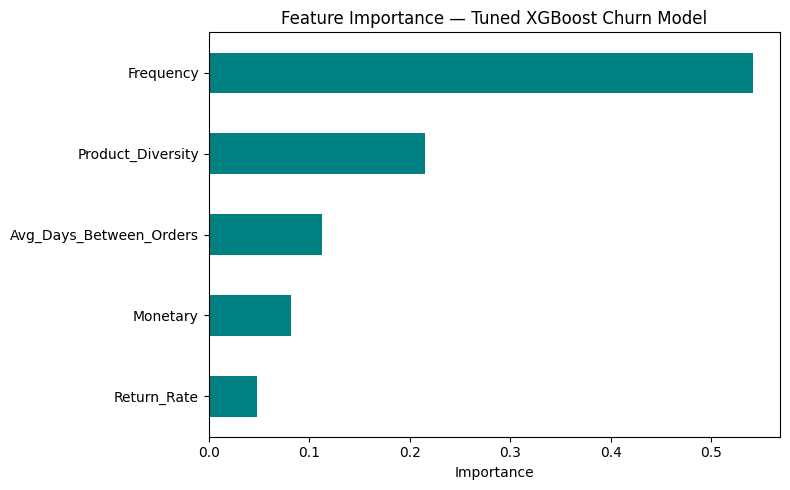

In [30]:
importances = pd.Series(best_xgb.feature_importances_, index=feature_cols_extended).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='teal')
plt.title("Feature Importance — Tuned XGBoost Churn Model")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Finding:** **Frequency** dominates (≈ 54% of total feature importance), followed by **Product_Diversity** (≈ 22%) and **Avg_Days_Between_Orders** (≈ 11%). The three engineered features together (≈ 38%) carry considerably more weight than Monetary (≈ 8%), while Return_Rate contributes the least (≈ 5%), suggesting that returns alone are a weak churn predictor in this dataset. In practical terms, customers who order less often and buy a narrower range of products are stronger churn candidates than customers who have simply spent less.

### 8.7 Results

Test accuracy improves from **69.5%** (baseline XGBoost, Frequency and Monetary only) to **72.3%** (tuned XGBoost, extended features), with a recall of **77.2%** on the churn class. Stratified 5-fold cross-validation gives a mean accuracy of **0.708** (standard deviation ≈ 0.007), indicating consistent performance across folds rather than dependence on a single split. The additional behavioural features, particularly Product_Diversity and Avg_Days_Between_Orders, contribute measurable signal beyond Frequency and Monetary.

## 9. Inventory Optimization

A reorder point is calculated for each product from its average daily demand and a fixed supplier lead time. The baseline formula is: Reorder Point = Average Daily Demand × Lead Time.

In [31]:
inventory = retail.groupby('Description').agg({
    'Quantity': 'sum',
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})
inventory.columns = ['Total_Quantity_Sold', 'Total_Orders', 'Total_Revenue']
inventory['Avg_Daily_Demand'] = inventory['Total_Quantity_Sold'] / 30

lead_time = 7
inventory['Reorder_Point_Baseline'] = inventory['Avg_Daily_Demand'] * lead_time

### 9.1 Safety Stock Buffer

The baseline formula assumes that demand equals its average every day. To account for day-to-day demand variability, a safety stock term is added:

`Safety Stock = Z × StdDev(Daily Demand) × √Lead Time`, with Z = 1.65 (≈ 95% service level)

`Reorder Point = Average Daily Demand × Lead Time + Safety Stock`

In [32]:
retail['OrderDate'] = retail['InvoiceDate'].dt.date
daily_demand = retail.groupby(['Description', 'OrderDate'])['Quantity'].sum().reset_index()
demand_std = daily_demand.groupby('Description')['Quantity'].std().fillna(0).rename('Daily_Demand_Std')

inventory = inventory.join(demand_std)
Z = 1.65
inventory['Safety_Stock'] = Z * inventory['Daily_Demand_Std'] * np.sqrt(lead_time)
inventory['Reorder_Point_With_Safety_Stock'] = inventory['Avg_Daily_Demand'] * lead_time + inventory['Safety_Stock']

top_inventory = inventory.sort_values('Total_Quantity_Sold', ascending=False).head(10)
top_inventory[['Total_Quantity_Sold', 'Avg_Daily_Demand', 'Reorder_Point_Baseline', 'Safety_Stock', 'Reorder_Point_With_Safety_Stock']]

,Total_Quantity_Sold,Avg_Daily_Demand,Reorder_Point_Baseline,Safety_Stock,Reorder_Point_With_Safety_Stock
Description,,,,,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185,3506.166667,24543.166667,2032.811288,26575.977955
WHITE HANGING HEART T-LIGHT HOLDER,91757,3058.566667,21409.966667,932.574782,22342.541449
"PAPER CRAFT , LITTLE BIRDIE",80995,2699.833333,18898.833333,0.000000,18898.833333
ASSORTED COLOUR BIRD ORNAMENT,78234,2607.800000,18254.600000,1048.769762,19303.369762
MEDIUM CERAMIC TOP STORAGE JAR,77916,2597.200000,18180.400000,30199.262048,48379.662048
JUMBO BAG RED RETROSPOT,74224,2474.133333,17318.933333,825.350607,18144.283941
BROCADE RING PURSE,70082,2336.066667,16352.466667,3821.465675,20173.932342
PACK OF 60 PINK PAISLEY CAKE CASES,54592,1819.733333,12738.133333,791.150322,13529.283656
60 TEATIME FAIRY CAKE CASES,52828,1760.933333,12326.533333,600.083134,12926.616468


**Finding:** For high-demand, high-variability products, the safety-stock-adjusted reorder point is materially higher than the baseline (for example, MEDIUM CERAMIC TOP STORAGE JAR rises from ≈ 18,180 to ≈ 48,380 units). The baseline formula would therefore under-order stock for products with volatile demand and risk stockouts during demand spikes.

## 10. Cohort Analysis

Customers are grouped by the month of their first purchase, and retention is tracked over subsequent months.

In [33]:
retail['OrderMonth'] = retail['InvoiceDate'].dt.to_period('M')
cohort_data = retail.groupby('Customer ID')['OrderMonth'].min().reset_index()
cohort_data.columns = ['Customer ID', 'CohortMonth']
retail_cohort = retail.merge(cohort_data, on='Customer ID')
retail_cohort['CohortIndex'] = (
    (retail_cohort['OrderMonth'].dt.year - retail_cohort['CohortMonth'].dt.year) * 12 +
    (retail_cohort['OrderMonth'].dt.month - retail_cohort['CohortMonth'].dt.month)
)

cohort_counts = retail_cohort.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

month1_retention = retention[1].mean()
print(f"Average Month-1 Retention Rate: {month1_retention:.1f}%")

Average Month-1 Retention Rate: 21.2%


## 11. Market Basket Analysis

Association rules are mined with the Apriori algorithm on the full cleaned dataset (all countries) and ranked by lift. To keep the one-hot transaction matrix computationally tractable (there are ~4,600 unique products), the analysis is scoped to the **200 most frequently sold products**, using `min_support = 0.02`.

In [34]:
from mlxtend.frequent_patterns import apriori, association_rules

top_n_products = retail['Description'].value_counts().head(200).index
basket_data = retail[retail['Description'].isin(top_n_products)]

basket = basket_data.groupby(['Invoice', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket_encoded = (basket > 0)

frequent_itemsets = apriori(basket_encoded, min_support=0.02, use_colnames=True)
print("Frequent itemsets found:", len(frequent_itemsets))

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)
print("Association rules found:", len(rules))

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

Frequent itemsets found: 224
Association rules found: 48


,antecedents,consequents,support,confidence,lift
8,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.023338,0.703598,24.009073
9,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.023338,0.796356,24.009073
6,frozenset({DOLLY GIRL LUNCH BOX}),frozenset({SPACEBOY LUNCH BOX }),0.021108,0.673347,19.347779
7,frozenset({SPACEBOY LUNCH BOX }),frozenset({DOLLY GIRL LUNCH BOX}),0.021108,0.606498,19.347779
3,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.022050,0.613636,18.766898
2,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.022050,0.674352,18.766898
41,frozenset({STRAWBERRY CERAMIC TRINKET BOX}),frozenset({SWEETHEART CERAMIC TRINKET BOX}),0.025662,0.449395,12.218093
40,frozenset({SWEETHEART CERAMIC TRINKET BOX}),frozenset({STRAWBERRY CERAMIC TRINKET BOX}),0.025662,0.697694,12.218093
47,frozenset({WOODEN FRAME ANTIQUE WHITE }),frozenset({WOODEN PICTURE FRAME WHITE FINISH}),0.031190,0.560068,10.754448
46,frozenset({WOODEN PICTURE FRAME WHITE FINISH}),frozenset({WOODEN FRAME ANTIQUE WHITE }),0.031190,0.598914,10.754448


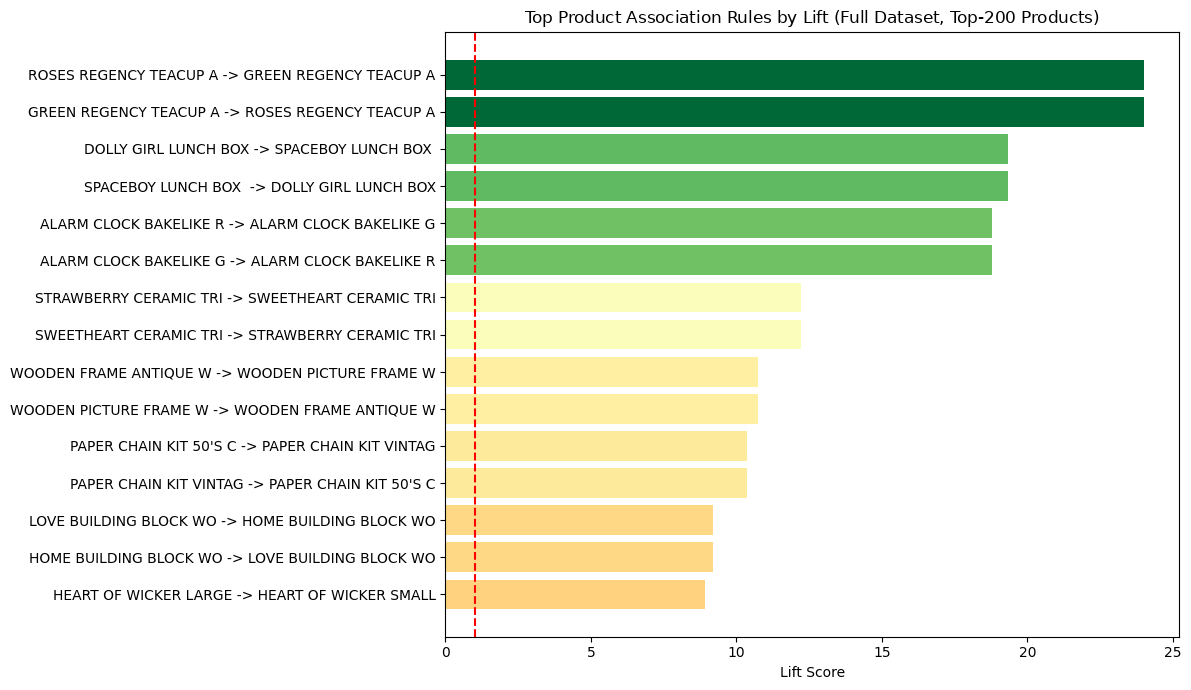

In [35]:
top_rules = rules.head(15).copy()
top_rules['rule'] = top_rules.apply(
    lambda x: f"{list(x['antecedents'])[0][:22]} -> {list(x['consequents'])[0][:22]}", axis=1
)
plt.figure(figsize=(12, 7))
plt.barh(top_rules['rule'], top_rules['lift'], color=plt.cm.RdYlGn(top_rules['lift'] / top_rules['lift'].max()))
plt.xlabel('Lift Score')
plt.title('Top Product Association Rules by Lift (Full Dataset, Top-200 Products)')
plt.axvline(x=1, color='red', linestyle='--')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Result:** The analysis yields 224 frequent itemsets and 48 association rules (lift ≥ 1). The strongest rules link variants of the same product family (for example, the Roses and Green Regency teacup and saucer sets, lift ≈ 24), which supports bundling and cross-sell recommendations.

## 12. Customer Lifetime Value (CLV) Prediction

The 12-month CLV is estimated as Average Order Value × Purchase Frequency (orders per month) × 12, and customers are segmented into CLV quartiles.

In [36]:
clv_data = retail.groupby('Customer ID').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Total_Orders=('Invoice', 'nunique'),
    Avg_Order_Value=('TotalPrice', 'mean'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max')
).reset_index()

clv_data['Lifespan_Days'] = (clv_data['Last_Purchase'] - clv_data['First_Purchase']).dt.days + 1
clv_data['Lifespan_Months'] = clv_data['Lifespan_Days'] / 30
clv_data['Purchase_Frequency'] = clv_data['Total_Orders'] / clv_data['Lifespan_Months'].clip(lower=1)
clv_data['CLV_12M'] = clv_data['Avg_Order_Value'] * clv_data['Purchase_Frequency'] * 12
clv_data['CLV_Segment'] = pd.qcut(clv_data['CLV_12M'], q=4, labels=['Low Value', 'Medium Value', 'High Value', 'Premium'])

clv_data[['Customer ID', 'Total_Revenue', 'Total_Orders', 'CLV_12M', 'CLV_Segment']].head(10)

,Customer ID,Total_Revenue,Total_Orders,CLV_12M,CLV_Segment
0,12346.0,77556.46,12,24574.146047,Premium
1,12347.0,4921.53,8,158.428972,High Value
2,12348.0,2019.40,5,196.344191,High Value
3,12349.0,4428.69,4,63.821002,Low Value
4,12350.0,334.40,1,236.047059,High Value
5,12351.0,300.93,1,171.960000,High Value
6,12352.0,2849.84,10,279.008567,Premium
7,12353.0,406.76,2,59.525854,Low Value
8,12354.0,1079.40,1,223.324138,High Value
9,12355.0,947.61,2,55.066925,Low Value


### 12.1 Sanity Check

The projected CLV values are checked for negative values, and the highest-CLV customers are inspected to assess whether the formula behaves reasonably.

In [37]:
print("Negative CLV_12M count:", (clv_data['CLV_12M'] < 0).sum())
clv_data['CLV_12M'].describe()

Negative CLV_12M count: 0


count      5878.000000
mean        583.545206
std        7609.001856
min           3.105562
25%          67.853358
50%         145.056762
75%         254.285902
max      478998.000000
Name: CLV_12M, dtype: float64

In [38]:
top_clv = clv_data.sort_values('CLV_12M', ascending=False).head(10)
top_clv[['Customer ID', 'Total_Orders', 'Lifespan_Days', 'Avg_Order_Value', 'Purchase_Frequency', 'CLV_12M']]

,Customer ID,Total_Orders,Lifespan_Days,Avg_Order_Value,Purchase_Frequency,CLV_12M
2722,15098.0,3,1,13305.500000,3.000000,478998.000000
4061,16446.0,2,205,56157.500000,0.292683,197236.097561
3382,15760.0,2,1,6958.170000,2.000000,166996.080000
569,12918.0,1,1,10953.500000,1.000000,131442.000000
2826,15202.0,3,1,2000.496667,3.000000,72017.880000
3618,16000.0,3,1,1377.077778,3.000000,49574.800000
3371,15749.0,3,98,4453.430000,0.918367,49078.616327
2819,15195.0,1,1,3861.000000,1.000000,46332.000000
389,12737.0,2,1,1855.250000,2.000000,44526.000000
5540,17949.0,118,737,752.013333,4.803256,43345.354681


In [39]:
distorted = clv_data[
    (clv_data['Total_Orders'] <= 3) &
    (clv_data['CLV_12M'] > clv_data['CLV_12M'].quantile(0.95))
]
print("Customers with only 1-3 real orders that still land in the top 5% CLV:", len(distorted))
distorted[['Customer ID', 'Total_Orders', 'Lifespan_Days', 'Avg_Order_Value', 'CLV_12M']].head(10)

Customers with only 1-3 real orders that still land in the top 5% CLV: 149


,Customer ID,Total_Orders,Lifespan_Days,Avg_Order_Value,CLV_12M
20,12366.0,1,1,166.746667,2000.960000
140,12487.0,1,1,142.650000,1711.800000
156,12503.0,1,1,563.000000,6756.000000
189,12536.0,3,16,48.282874,1738.183448
208,12555.0,1,1,129.230000,1550.760000
243,12590.0,2,1,145.062647,3481.503529
256,12603.0,1,1,369.600000,4435.200000
289,12636.0,1,1,141.000000,1692.000000
389,12737.0,2,1,1855.250000,44526.000000
470,12818.0,1,1,110.148571,1321.782857


**Finding:** There are no negative CLV values. However, the formula overstates CLV for customers with very few orders placed close together in time. Because `Lifespan_Months` is floored at one month, a customer who placed two or three large orders within a single month receives a `Purchase_Frequency` of two to three orders per month, and the formula then projects that pace over a full 12 months, which is unrealistic for what are likely one-off bulk purchases. In this dataset, 149 customers with only 1–3 orders fall within the top 5% of projected CLV. `CLV_12M` is therefore reliable for customers with a genuine multi-month order history, but should be interpreted with caution for new or one-time buyers. An alternative is to use the dataset's overall observation window instead of a one-month floor.

## 13. Summary of Results and Limitations

| Module | Method | Key Result |
|---|---|---|
| Data cleaning | De-duplication; removal of missing Customer IDs, non-positive quantity/price and cancelled invoices | 1,067,371 raw records reduced to 779,425 cleaned records |
| Missing Customer ID assessment | Comparison of excluded vs retained rows | Excluded rows have far lower average quantity and value; customer-level results represent identified customers |
| RFM segmentation | Quartile scores with rule-based segments | 5,878 customers: Regular 2,930; Potential 894; At Risk 880; VIP 659; Loyal 515 |
| KMeans clustering | k = 3, Elbow method with Silhouette validation | Loyal 3,847; At Risk 2,009; VIP 22; Silhouette Score ≈ 0.58 |
| Demand forecasting | Prophet with six-month holdout | MAPE ≈ 25.2%; September–November peak is underpredicted |
| Churn prediction | Tuned XGBoost, five leakage-free features | Accuracy 72.3%, churn recall 77.2%; 5-fold CV accuracy 0.708 ± 0.007 |
| Inventory optimization | Reorder point with safety stock (Z = 1.65, 7-day lead time) | Reorder points are materially higher for volatile-demand products |
| Cohort analysis | Monthly acquisition cohorts | Average month-1 retention ≈ 21.2% |
| Market basket analysis | Apriori on the top 200 products (min_support = 0.02) | 224 frequent itemsets, 48 rules; highest lift ≈ 24 |
| CLV estimation | 12-month projection with sanity check | 149 customers with 1–3 orders fall in the top 5% of CLV (one-month lifespan floor effect) |

**Limitations**

- Customer-level analyses (RFM, clustering, churn, CLV) exclude transactions without a Customer ID (~23% of rows).
- The forecast has a MAPE of ≈ 25% because of the short (~19 month) training history. It should be treated as a trend-level estimate.
- The churn label is a fixed 90-day inactivity rule; reported performance reflects that definition.
- CLV is overstated for one-time bulk buyers because of the one-month lifespan floor.
- Inventory calculations rely on fixed business assumptions (7-day lead time, 30-day demand normalisation, 95% service level).